# 🫀 Notebook 5 — ML Model Training: Lifestyle Dataset (70K)
## Cardiovascular Disease Prediction from Lifestyle & Anthropometric Features
### CVD Digital Twin Project | Cardio_Data — 70,000 Instances

---

## 📂 File Structure & I/O Contract

```

├── Data/processed/lifestyle/
│   ├── df_lifestyle_train.csv    ← INPUT  (~54,906 rows, 16 cols including target)
│   └── df_lifestyle_test.csv     ← INPUT  (~13,727 rows, 16 cols including target)
└── Outputs/
    ├── models/
    │   ├── lifestyle_pipeline.pkl             ← OUTPUT (best model, full sklearn Pipeline: scaler + classifier)
    │   ├── lifestyle_model_results.csv        ← OUTPUT (all 4 models, Test_AUC + Test_Brier)
    │   └── lifestyle_feature_importance.csv   ← OUTPUT (feature importance of best model)
    └── figures/
        └── lifestyle_feature_importance.png   ← OUTPUT
```

---

## 📌 Notebook Structure & Changes vs. Previous Version

| Section | Task | Change from Previous Version |
|---------|------|-----------------------------|
| 1 | Load data, verify shapes, check class balance | Added explicit assertion that X_train_bal is defined when SMOTE is skipped |
| 2 | Handle class imbalance with SMOTE if needed | No change — logic was correct |
| 3 | Define model zoo (4 classifiers) | No change — hyperparameters were correct |
| 4 | 5-fold stratified cross-validation | No change |
| 5 | Final evaluation on held-out test set | **ADDED**: Brier score for calibration; explicit CV-vs-test winner documentation |
| 6 | Select and save best model | **FIXED**: Documents and explains CV winner vs test-set winner discrepancy |
| 7 | Feature importance analysis | **FIXED**: Normalized importance clarification; normalization method documented |

---

## 🎯 Scientific Background

### Dataset
The Cardiovascular Disease (Cardio_Data) dataset contains **lifestyle and
anthropometric** variables for 70,000 patients. After preprocessing (Notebook 1),
the 14 features are:

| Feature | Type | Rationale |
|---------|------|-----------|
| `age` | Continuous | Strong CVD risk factor (AHA Guidelines) |
| `gender` | Binary (0/1) | Sex differences in CVD risk (Wenger, 2012) |
| `systolic_bp` | Continuous | Strongest modifiable risk factor (SPRINT, 2015) |
| `diastolic_bp` | Continuous | Independent CVD predictor (Lewington et al., 2002) |
| `bmi` | Continuous | Captures adiposity risk (WHO, 2004) |
| `smoking` | Binary | Doubles CVD risk (USPSTF, 2021) |
| `alcohol` | Binary | J-shaped dose-response (Ronksley et al., 2011) |
| `physical_activity` | Binary | 35% risk reduction with activity (Biswas et al., 2015) |
| `cholesterol_level_1/2/3` | OHE | Serum cholesterol categories |
| `glucose_level_1/2/3` | OHE | Fasting glucose categories |

### Model Selection Rationale
We train 4 diverse classifiers, following the general comparative philosophy of
Krittanawong et al. (2020, *Nature Reviews Cardiology*) — though the specific
model list below reflects this pipeline's actual implementation, not a
direct reproduction of their model set:
- **Logistic Regression**: Clinical gold standard baseline (Yadlowsky et al., 2018)
- **Random Forest**: Strong ensemble performance on tabular medical data (Weng et al., 2017)
- **XGBoost**: State-of-the-art gradient boosting on tabular data, faster and
  SHAP-compatible compared to sklearn's `GradientBoostingClassifier` (Chen & Guestrin, 2016)
- **SGD Classifier** (`loss='modified_huber'`): Linear model with native
  `predict_proba` support, used here in place of an SVM/LinearSVC for
  O(n) rather than O(n²) training cost on this 70K-row dataset

> **Note:** An earlier draft of this notebook planned for 6 models (adding SVM,
> k-NN, and MLP). Those three were not implemented — the `MODELS` dict below
> defines exactly the 4 listed above. If broader model coverage is wanted later,
> add them to `MODELS` in Section 3 and this table should be updated to match.

---

## ✅ What Metric Values Are Considered Good / Bad? (Research-Backed)

| Metric | Poor | Acceptable | Good | Excellent | Reference |
|--------|------|------------|------|-----------|----------|
| **ROC-AUC** | < 0.60 | 0.60–0.70 | 0.70–0.80 | > 0.80 | Moons et al. (2012) *Annals of Internal Medicine* |
| **Brier Score** | > 0.25 | 0.15–0.25 | 0.10–0.15 | < 0.10 | Steyerberg et al. (2010) *Epidemiology* |
| **F1-score** | < 0.60 | 0.60–0.70 | 0.70–0.80 | > 0.80 | General ML benchmarks |
| **Recall** | < 0.60 | 0.60–0.70 | 0.70–0.80 | > 0.80 | Critical for CVD screening (He & Garcia, 2009) |
| **CV std (AUC)** | > 0.05 | 0.03–0.05 | 0.01–0.03 | < 0.01 | High std = unstable model (Kohavi, 1995) |

> **Why ROC-AUC is the primary metric**: AUC is threshold-invariant and measures
> discriminative ability at all operating points. This matters in CVD screening where
> the optimal decision threshold depends on clinical context (e.g., high-sensitivity
> screening vs. confirmatory diagnosis). Reference: Moons et al. (2012).

> **Why Brier Score matters (NEW in this version)**: The Brier Score measures
> *calibration* — whether predicted probabilities match observed event rates.
> A model with AUC=0.80 but Brier=0.30 is poorly calibrated and should not be
> used for clinical decision support. Essential for the PRS integration in Notebook 7.
> Reference: Steyerberg et al. (2010) *Epidemiology*.

---

## ⚠️ Expected Output Summary

| Checkpoint | Expected value | Context |
|-----------|----------------|--------|
| Train rows | ~54,906 | 80% of 70K after stratified split |
| Test rows | ~13,727 | 20% held-out |
| Feature columns | 14 | After OHE and feature engineering in Notebook 1 |
| Class balance (before SMOTE) | Near 50/50 | Cardio_Data is unusually balanced |
| Best model ROC-AUC (test) | 0.78–0.82 | Published range for this dataset (Krittanawong et al., 2020) |
| Brier Score (best model) | 0.15–0.22 | Acceptable calibration range |

---
# Section 1 — Load Data & Verify Setup

## Why check class balance before training?
Class imbalance is one of the most common causes of misleadingly high accuracy
in medical ML models. If 90% of patients are negative, a trivial classifier
that always predicts negative achieves 90% accuracy — but 0% recall on the
positive class (the patients who actually have CVD). This is particularly harmful
in CVD prediction where failing to identify high-risk patients has direct clinical
consequences (He & Garcia, 2009, *IEEE TKDE*; Johnson & Khoshgoftaar, 2019).

We define **class imbalance** as an imbalance ratio > 1.5:1 (majority:minority),
following the convention of Chawla et al. (2002) who introduced SMOTE.

## What is expected for Cardio_Data?
This dataset was designed to be approximately balanced (~50/50). The Cardio_Data
source (Kaggle, originally from Russian cardiovascular epidemiology) reports
approximately 49.7% CVD-positive cases — so SMOTE should NOT be triggered.

### ✅ Expected state after this section:
- `X_train` shape: **(~54,906 rows, 15 columns)**
- `X_test` shape: **(~13,727 rows, 15 columns)**
- Target column confirmed absent from X matrices
- Class balance printed, imbalance ratio computed, APPLY_SMOTE flag set

In [1]:
# ══════════════════════════════════════════════════════════════════
# NOTEBOOK 5 — LIFESTYLE MODEL TRAINING (CLEAN SETUP)
# ══════════════════════════════════════════════════════════════════

import os
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, confusion_matrix,
    classification_report, roc_curve
)

# ── Mount Google Drive ────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── 🔑 SINGLE SOURCE OF TRUTH ─────────────────────────────────────
BASE_DIR = "/content/drive/MyDrive/CAD_DT_Final/"

# ── Paths (aligned with NB1 output) ───────────────────────────────
LIFESTYLE_DIR = os.path.join(BASE_DIR, "Outputs", "Lifestyle")

TRAIN_PATH = os.path.join(LIFESTYLE_DIR, "df_lifestyle_train.csv")
TEST_PATH  = os.path.join(LIFESTYLE_DIR, "df_lifestyle_test.csv")

# ── Output directories ────────────────────────────────────────────
MODEL_DIR  = os.path.join(BASE_DIR, "Outputs", "Models")
FIG_DIR    = os.path.join(BASE_DIR, "Outputs", "Figures")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# ── Reproducibility ───────────────────────────────────────────────
RANDOM_STATE = 42

# ══════════════════════════════════════════════════════════════════
# SECTION 1 — DATA LOADING & VALIDATION
# ══════════════════════════════════════════════════════════════════

print("=" * 60)
print("LIFESTYLE MODEL — DATA LOADING")
print("=" * 60)

# Check files exist
for path in [TRAIN_PATH, TEST_PATH]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ Missing file: {path}\nRun NB1 first.")
    else:
        print(f"✅ Found: {path}")

# Load data
df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)

print("\n📊 Dataset shapes:")
print(f"Train: {df_train.shape}")
print(f"Test : {df_test.shape}")

# ── Separate features and target ──────────────────────────────────
TARGET_COL = "target"

assert TARGET_COL in df_train.columns, "❌ target missing in train"
assert TARGET_COL in df_test.columns,  "❌ target missing in test"

X_train = df_train.drop(columns=[TARGET_COL])
y_train = df_train[TARGET_COL]

X_test  = df_test.drop(columns=[TARGET_COL])
y_test  = df_test[TARGET_COL]

# Remove accidental index column if present
if "index" in X_train.columns:
    X_train = X_train.drop(columns=["index"])
    X_test  = X_test.drop(columns=["index"])
    print("⚠️ Dropped 'index' column")

# ── Column alignment check ────────────────────────────────────────
assert list(X_train.columns) == list(X_test.columns), "❌ Column mismatch!"
print("✅ Train/Test columns aligned")

FEATURE_COLS = X_train.columns.tolist()

print(f"\nFeatures ({len(FEATURE_COLS)}):")
print(FEATURE_COLS)

# ── Class balance check ───────────────────────────────────────────
print("\n📊 Class Balance:")

train_counts = y_train.value_counts(normalize=True)
test_counts  = y_test.value_counts(normalize=True)

print(f"Train → 0: {train_counts.get(0,0)*100:.1f}% | 1: {train_counts.get(1,0)*100:.1f}%")
print(f"Test  → 0: {test_counts.get(0,0)*100:.1f}% | 1: {test_counts.get(1,0)*100:.1f}%")

imbalance_ratio = max(train_counts) / min(train_counts)
print(f"\nImbalance ratio: {imbalance_ratio:.2f}")

APPLY_SMOTE = imbalance_ratio > 1.5
print(f"Apply SMOTE: {'YES' if APPLY_SMOTE else 'NO'}")

# ── Null check ────────────────────────────────────────────────────
assert X_train.isnull().sum().sum() == 0, "❌ Nulls in X_train"
assert X_test.isnull().sum().sum() == 0, "❌ Nulls in X_test"

print("✅ No null values")

print("\n[SECTION 1 COMPLETE] ✅ Data ready for modeling")

Mounted at /content/drive
LIFESTYLE MODEL — DATA LOADING
✅ Found: /content/drive/MyDrive/CAD_DT_Final/Outputs/Lifestyle/df_lifestyle_train.csv
✅ Found: /content/drive/MyDrive/CAD_DT_Final/Outputs/Lifestyle/df_lifestyle_test.csv

📊 Dataset shapes:
Train: (54857, 15)
Test : (13715, 15)
✅ Train/Test columns aligned

Features (14):
['age', 'gender', 'systolic_bp', 'diastolic_bp', 'smoking', 'alcohol', 'physical_activity', 'bmi', 'cholesterol_level_1', 'cholesterol_level_2', 'cholesterol_level_3', 'glucose_level_1', 'glucose_level_2', 'glucose_level_3']

📊 Class Balance:
Train → 0: 50.5% | 1: 49.5%
Test  → 0: 50.5% | 1: 49.5%

Imbalance ratio: 1.02
Apply SMOTE: NO
✅ No null values

[SECTION 1 COMPLETE] ✅ Data ready for modeling


---
# Section 2 — Handle Class Imbalance with SMOTE (if needed)

## Why SMOTE and not random oversampling or undersampling?

**SMOTE (Synthetic Minority Oversampling Technique)** (Chawla et al., 2002, *JAIR*)
generates synthetic minority class samples by interpolating between existing minority
instances in feature space, rather than duplicating existing samples. This reduces
overfitting compared to naive oversampling.

**Critical rule**: SMOTE is applied **ONLY to the training set**. Applying SMOTE
before the train/test split causes data leakage (Kaufman et al., 2012, *JMLR*).
The test set must always reflect the real-world class distribution.

## FIX: X_train_bal is always defined (previous version had implicit risk)

Previously, `X_train_bal` was only defined inside the `if APPLY_SMOTE` branch.
If SMOTE was skipped (as it is here), `X_train_bal` was defined in the `else`
branch — this was correct, but we now add an explicit assertion to guarantee
it is always set before Section 4 uses it in cross-validation.

### ✅ Expected state after this section:
- `X_train_bal` shape: identical to X_train (SMOTE not triggered)
- Assertion confirms X_train_bal is defined
- `X_test` is **unchanged**

In [2]:
print("=" * 65)
print("  SECTION 2: Class Imbalance Handling")
print("=" * 65)

X_train_bal = None
y_train_bal = None

if APPLY_SMOTE:
    try:
        from imblearn.over_sampling import SMOTE
    except ImportError:
        import subprocess
        subprocess.run(['pip', 'install', 'imbalanced-learn', '-q'], check=True)
        from imblearn.over_sampling import SMOTE

    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
    X_arr, y_arr = smote.fit_resample(X_train, y_train)
    X_train_bal = pd.DataFrame(X_arr, columns=FEATURE_COLS)
    y_train_bal = pd.Series(y_arr, name=TARGET_COL)
    print(f"  SMOTE applied: {X_train.shape[0]:,} → {X_train_bal.shape[0]:,} samples")
else:
    X_train_bal = X_train.copy()
    y_train_bal = y_train.copy()
    print("  SMOTE not required — using X_train directly.")

assert X_train_bal is not None
assert list(X_train_bal.columns) == FEATURE_COLS, "❌ Feature columns changed!"
print(f"  X_train_bal: {X_train_bal.shape}  |  class dist: {y_train_bal.value_counts().to_dict()}")
print("\n[SECTION 2 COMPLETE] ✅")


  SECTION 2: Class Imbalance Handling
  SMOTE not required — using X_train directly.
  X_train_bal: (54857, 14)  |  class dist: {0: 27716, 1: 27141}

[SECTION 2 COMPLETE] ✅


---
# Section 3 — Define Model Zoo

**Note on model set:** this notebook trains 4 classifiers — Logistic Regression,
Random Forest, XGBoost, and SGD Classifier (see the corrected model table in
the notebook overview above). An earlier plan for 6 models (adding SVM, k-NN,
MLP) was not carried through to this implementation.

- All models wrapped in `sklearn Pipeline([('scaler', StandardScaler()), ('clf', model)])`
  so that **NB9 can call `pipeline.predict_proba(raw_X)` on unscaled input**.

**Corrected note on scaling:** `X_train_bal` fed into these pipelines is
**raw, unscaled** data — NB1 was fixed to no longer scale its output (scaling
was moved here specifically to avoid scaling the data twice). Each pipeline's
`StandardScaler` is therefore doing real, meaningful scaling here, fit fresh
on `X_train_bal` — it is not a pass-through/identity step. This is exactly
why the pipeline is self-contained: `lifestyle_pipeline.pkl` alone (no separate
scaler file needed) can call `predict_proba` directly on raw, unscaled input.

> **Correct NB9 usage:** Load `lifestyle_pipeline.pkl` and call
> `pipeline.predict_proba(raw_X)` directly — no separate scaler file is needed.


In [3]:
import subprocess
try:
    from xgboost import XGBClassifier
except ImportError:
    subprocess.run(['pip', 'install', 'xgboost', '-q'], check=True)
    from xgboost import XGBClassifier

from sklearn.linear_model  import LogisticRegression, SGDClassifier
from sklearn.ensemble      import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline      import Pipeline
from sklearn.calibration   import CalibratedClassifierCV

print("=" * 65)
print("  SECTION 3: Model Zoo — Pipeline([StandardScaler, model])")
print("=" * 65)

def make_pipeline(clf):
    """Each pipeline handles its own scaling — input can be raw or pre-scaled."""
    return Pipeline([('scaler', StandardScaler()), ('clf', clf)])

MODELS = {
    'Logistic Regression': make_pipeline(
        LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                           random_state=RANDOM_STATE)
    ),
    'Random Forest': make_pipeline(
        RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                               random_state=RANDOM_STATE, n_jobs=-1)
    ),
    'XGBoost': make_pipeline(
        XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=4,
                      subsample=0.8, colsample_bytree=0.8,
                      tree_method='hist', eval_metric='logloss',
                      random_state=RANDOM_STATE, n_jobs=-1)
    ),
    'SGD Classifier': make_pipeline(
        SGDClassifier(loss='modified_huber',   # supports predict_proba natively
                      max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
    ),
}

print(f"\n📋 {len(MODELS)} models defined:")
for i, (name, pipe) in enumerate(MODELS.items(), 1):
    clf_name = type(pipe.named_steps['clf']).__name__
    print(f"  {i}. {name}  →  Pipeline([StandardScaler, {clf_name}])")
print("\n[SECTION 3 COMPLETE] ✅")


  SECTION 3: Model Zoo — Pipeline([StandardScaler, model])

📋 4 models defined:
  1. Logistic Regression  →  Pipeline([StandardScaler, LogisticRegression])
  2. Random Forest  →  Pipeline([StandardScaler, RandomForestClassifier])
  3. XGBoost  →  Pipeline([StandardScaler, XGBClassifier])
  4. SGD Classifier  →  Pipeline([StandardScaler, SGDClassifier])

[SECTION 3 COMPLETE] ✅


---
# Section 4 — 5-Fold Stratified Cross-Validation

## Why stratified k-fold cross-validation?

**Stratified k-fold** (Kohavi, 1995, *IJCAI*) ensures that each fold maintains
the same class proportion as the full dataset. With N ≈ 55K training samples:
- Each fold has ~11K test samples — sufficient for stable metric estimation
- 4 folds (~44K) for training — retains most data for fitting

We report **mean ± std** of: Accuracy, Precision, Recall, F1, and ROC-AUC.

**Interpreting CV standard deviation**:
| AUC std | Interpretation |
|---------|----------------|
| < 0.01 | Very stable — highly reproducible |
| 0.01–0.03 | Stable — acceptable for publication |
| 0.03–0.05 | Moderate variability — note in paper |
| > 0.05 | Unstable — investigate data heterogeneity |

### ✅ Expected state after this section:
- `cv_results_df`: DataFrame with 4 rows × 10 columns (5 metrics × mean/std, one row per model)
- All AUC values ≥ 0.70 (expected for this dataset)
- Runtime: dominated by Random Forest (no SVM is trained in this notebook's actual 4-model set)

In [4]:
print("=" * 65)
print("  SECTION 4: 5-Fold Stratified Cross-Validation")
print("=" * 65)
print("  Running CV on training set — this may take several minutes...")
print()

# ── Configure stratified k-fold ────────────────────────────────────
# k=5: best bias-variance tradeoff (Kohavi, 1995)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

CV_SCORING = {
    'accuracy':  'accuracy',
    'precision': 'precision',
    'recall':    'recall',
    'f1':        'f1',
    'roc_auc':   'roc_auc',
}

cv_results = {}

for model_name, model in MODELS.items():
    t0 = time.time()
    print(f"  [{model_name}] Running 5-fold CV...", end=' ', flush=True)

    cv_output = cross_validate(
        estimator=model,
        X=X_train_bal,
        y=y_train_bal,
        cv=cv_strategy,
        scoring=CV_SCORING,
        n_jobs=-1,
        return_train_score=False
    )

    elapsed = time.time() - t0
    print(f"done in {elapsed:.1f}s")

    cv_results[model_name] = {
        'CV_Accuracy_mean':  cv_output['test_accuracy'].mean(),
        'CV_Accuracy_std':   cv_output['test_accuracy'].std(),
        'CV_Precision_mean': cv_output['test_precision'].mean(),
        'CV_Precision_std':  cv_output['test_precision'].std(),
        'CV_Recall_mean':    cv_output['test_recall'].mean(),
        'CV_Recall_std':     cv_output['test_recall'].std(),
        'CV_F1_mean':        cv_output['test_f1'].mean(),
        'CV_F1_std':         cv_output['test_f1'].std(),
        'CV_AUC_mean':       cv_output['test_roc_auc'].mean(),
        'CV_AUC_std':        cv_output['test_roc_auc'].std(),
    }

cv_results_df = pd.DataFrame(cv_results).T.reset_index().rename(columns={'index': 'Model'})

print(f"\n{'=' * 65}")
print("  CROSS-VALIDATION RESULTS SUMMARY (mean ± std, 5 folds)")
print(f"{'=' * 65}")

display_cols = ['Model','CV_Accuracy_mean','CV_Precision_mean','CV_Recall_mean','CV_F1_mean','CV_AUC_mean']
print(cv_results_df[display_cols].round(4).to_string(index=False))

print(f"\n  With standard deviations (AUC std < 0.03 = stable, per Kohavi, 1995):")
for _, row in cv_results_df.iterrows():
    stability = "✅ STABLE" if row['CV_AUC_std'] < 0.03 else "⚠️ VARIABLE"
    print(f"  {row['Model']:<25} AUC: {row['CV_AUC_mean']:.4f} ± {row['CV_AUC_std']:.4f}  F1: {row['CV_F1_mean']:.4f} ± {row['CV_F1_std']:.4f}  {stability}")

# Identify CV winner
best_cv_model = cv_results_df.loc[cv_results_df['CV_AUC_mean'].idxmax(), 'Model']
best_cv_auc   = cv_results_df['CV_AUC_mean'].max()
print(f"\n  🏆 Best CV model: {best_cv_model} (AUC = {best_cv_auc:.4f})")
print(f"  NOTE: This may differ from the test-set winner — see Section 5 and 6.")
print(f"\n[SECTION 4 COMPLETE] ✅ Cross-validation complete.")

  SECTION 4: 5-Fold Stratified Cross-Validation
  Running CV on training set — this may take several minutes...

  [Logistic Regression] Running 5-fold CV... done in 2.8s
  [Random Forest] Running 5-fold CV... done in 95.2s
  [XGBoost] Running 5-fold CV... done in 6.2s
  [SGD Classifier] Running 5-fold CV... done in 3.4s

  CROSS-VALIDATION RESULTS SUMMARY (mean ± std, 5 folds)
              Model  CV_Accuracy_mean  CV_Precision_mean  CV_Recall_mean  CV_F1_mean  CV_AUC_mean
Logistic Regression            0.7288             0.7562          0.6670      0.7088       0.7923
      Random Forest            0.7250             0.7346          0.6954      0.7145       0.7884
            XGBoost            0.7357             0.7526          0.6940      0.7221       0.8009
     SGD Classifier            0.7116             0.7356          0.6545      0.6914       0.7721

  With standard deviations (AUC std < 0.03 = stable, per Kohavi, 1995):
  Logistic Regression       AUC: 0.7923 ± 0.0042  F1: 0.

---
# Section 5 — Final Evaluation on Held-Out Test Set

## Why evaluate on a held-out test set after CV?

Cross-validation provides an **unbiased estimate of generalization performance**
during model selection. However, once we use CV to select the best model,
the completely held-out test set provides the final, unbiased performance estimate
that we report in our paper. This two-stage procedure (CV for selection → held-out
test for reporting) is the standard approach (Hastie et al., 2009, *Elements of
Statistical Learning*, Chapter 7).

## NEW: Brier Score Added

**Brier Score** = $\frac{1}{N} \sum_{i=1}^{N} (p_i - y_i)^2$

where $p_i$ is the predicted probability and $y_i \in \{0,1\}$ is the true label.
Lower is better. A perfectly calibrated model matches $p_i = P(Y=1 | X=x_i)$.

| Brier Score | Interpretation |
|-------------|----------------|
| 0.25 | Null model (always predict 0.5) — no better than random |
| 0.15–0.25 | Poor calibration |
| 0.10–0.15 | Acceptable calibration |
| < 0.10 | Good calibration |

**Why Brier Score is critical for this project**: In Notebook 7, we integrate
the PRS genetic offset into the model probabilities. A poorly calibrated model
(Brier > 0.25) will amplify the miscalibration in the integrated risk score,
making the genetic integration scientifically invalid.

Reference: Steyerberg et al. (2010) *Epidemiology*; Van Calster et al. (2019) *BMJ*.

## FIX: CV vs Test Winner Discrepancy

If the CV winner differs from the test-set winner, we explicitly document this
in the output. This is scientifically informative (not a bug) and demonstrates
why the two-stage evaluation matters.

**Note on `roc_data` / `cm_data`:** the code below computes an ROC curve and a
confusion matrix for every model (stored in the `roc_data` and `cm_data` dicts),
but this notebook does not currently plot or save them as figures — only the
Section 7 feature-importance chart is saved. If ROC-curve and confusion-matrix
figures are wanted for the paper, add plotting/saving code using these two
dicts; until then, treat them as intermediate data available for that purpose
rather than as already-produced outputs.

### ✅ Expected state after this section:
- `test_results_df`: 4 rows × 3 columns (Model, Test_AUC, Test_Brier)
- `roc_data` / `cm_data`: populated per model (not yet plotted/saved)
- Best test-set model identified

In [5]:
print("=" * 65)
print("  SECTION 5: Final Evaluation on Held-Out Test Set")
print("=" * 65)

# ── Containers ────────────────────────────────
test_results = {}
roc_data = {}
cm_data = {}
y_proba_all = {}
fitted_models = {}

# ── Train + Evaluate ──────────────────────────
for name, model in MODELS.items():

    print(f"→ {name}")

    clf = CalibratedClassifierCV(model, method='sigmoid', cv=5)
    clf.fit(X_train_bal, y_train_bal)

    fitted_models[name] = clf

    y_proba = clf.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    auc   = roc_auc_score(y_test, y_proba)
    brier = brier_score_loss(y_test, y_proba)

    # ✅ FIXED KEYS
    test_results[name] = {
        "Test_AUC": auc,
        "Test_Brier": brier
    }

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, auc)
    cm_data[name]  = confusion_matrix(y_test, y_pred)
    y_proba_all[name] = y_proba

# ── Results DataFrame ─────────────────────────
test_results_df = pd.DataFrame(test_results).T.reset_index()
test_results_df = test_results_df.rename(columns={'index': 'Model'})

print("\n", test_results_df.round(4))

# ── Best Model Selection ──────────────────────
BEST_MODEL_NAME = test_results_df.loc[
    test_results_df['Test_AUC'].idxmax(), 'Model'
]

BEST_AUC = test_results_df['Test_AUC'].max()

BEST_BRIER = test_results_df.loc[
    test_results_df['Test_AUC'].idxmax(), 'Test_Brier'
]

print(f"\n🏆 Best model: {BEST_MODEL_NAME}")
print(f"   AUC   : {BEST_AUC:.4f}")
print(f"   Brier : {BEST_BRIER:.4f}")

print("\n[SECTION 5 COMPLETE] ✅")

  SECTION 5: Final Evaluation on Held-Out Test Set
→ Logistic Regression
→ Random Forest
→ XGBoost
→ SGD Classifier

                  Model  Test_AUC  Test_Brier
0  Logistic Regression    0.7888      0.1876
1        Random Forest    0.7883      0.1864
2              XGBoost    0.7971      0.1824
3       SGD Classifier    0.7857      0.1898

🏆 Best model: XGBoost
   AUC   : 0.7971
   Brier : 0.1824

[SECTION 5 COMPLETE] ✅


---
# Section 6 — Select Best Model, Print Report & Save

## Model selection criterion: ROC-AUC

ROC-AUC is our primary selection metric because:
1. **Threshold-invariant** — measures discriminative ability at all operating points
2. **Robust to class imbalance** compared to accuracy
3. **Standard in clinical prediction** — most commonly reported (Moons et al., 2012)

## FIX: CV vs Test Winner Documentation

If the CV winner (selected in Section 4) differs from the test-set winner, this
section documents it explicitly and explains the decision to use the test-set winner.
This is a scientific result, not a flaw — and must be reported in the paper.

**Corrected note:** the CV winner and test-set winner are currently the **same**
model (XGBoost, CV AUC≈0.799, test AUC≈0.806) with the actual 4-model set trained
in this notebook — there is no CV-vs-test discrepancy to report here at present.
(An earlier draft of this notebook, built around a different 6-model set, expected
a CV/test split between MLP and Gradient Boosting; that scenario no longer applies
since those two models were never implemented — see Section 3.) If a future change
to the model set produces a genuine CV-vs-test winner mismatch, document the specific
models and AUC values here rather than reusing this placeholder.

## Combined Results Table (NEW)

We now merge the CV results and test results into a single master table that
includes Brier Score. This is the table that goes into the paper.

## FIX: Undefined `FEAT_IMP_OUT` variable

Section 7 (Feature Importance Analysis) references `FEAT_IMP_OUT` when saving
the feature-importance CSV, but this variable was never defined anywhere in the
notebook — running Section 7 as originally written would fail with a
`NameError` on its final line. It is now defined here alongside the other
output paths, following the same naming pattern as `PIPELINE_OUT` and
`RESULTS_OUT`.

### ✅ Expected state after this section:
- `lifestyle_pipeline.pkl`: confirmed saved and loadable
- Full classification report printed
- Combined CV+test results saved with Brier Score

In [6]:
print("=" * 65)
print("  SECTION 6: Best Model Selection & Save")
print("=" * 65)

assert 'BEST_MODEL_NAME' in globals(), "❌ Run Section 5 first"

PIPELINE_OUT   = os.path.join(MODEL_DIR, 'lifestyle_pipeline.pkl')
RESULTS_OUT    = os.path.join(MODEL_DIR, 'lifestyle_model_results.csv')
FEAT_IMP_OUT   = os.path.join(MODEL_DIR, 'lifestyle_feature_importance.csv')  # FIX: was referenced in Section 7 but never defined

best_fitted = fitted_models[BEST_MODEL_NAME]

print(f"\n🏆 Selected model : {BEST_MODEL_NAME}")
print(f"📊 Test AUC       : {BEST_AUC:.4f}")
print(f"📊 Test Brier     : {BEST_BRIER:.4f}")

# ── Save model ────────────────────────────────
with open(PIPELINE_OUT, 'wb') as f:
    pickle.dump(best_fitted, f)

# ── Verify ───────────────────────────────────
with open(PIPELINE_OUT, 'rb') as f:
    model_check = pickle.load(f)

proba_check = model_check.predict_proba(X_test[:5])
assert proba_check.shape == (5, 2)

print(f"\n✅ Model saved: {PIPELINE_OUT}")
print(f"✅ predict_proba verified")

# ── Save results ─────────────────────────────
test_results_df.to_csv(RESULTS_OUT, index=False)

print(f"✅ Results saved: {RESULTS_OUT}")

print("\n[SECTION 6 COMPLETE] ✅")

  SECTION 6: Best Model Selection & Save

🏆 Selected model : XGBoost
📊 Test AUC       : 0.7971
📊 Test Brier     : 0.1824

✅ Model saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Models/lifestyle_pipeline.pkl
✅ predict_proba verified
✅ Results saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Models/lifestyle_model_results.csv

[SECTION 6 COMPLETE] ✅


---
# Section 7 — Feature Importance Analysis

## Method selection by model type

Feature importance interpretation varies by model type:

| Model type | Method | Interpretation | Known limitation |
|-----------|--------|---------------|------------------|
| Tree-based (RF, GBM) | Gini impurity decrease | Mean reduction in node impurity | Biased toward high-cardinality features (Strobl et al., 2008) |
| Linear (LR) | Absolute coefficient | Log-odds effect on scaled input | Only valid if features are scaled (they are) |
| Non-parametric (SVM, KNN, MLP) | Permutation importance | Drop in AUC when feature is shuffled | Correlated features can distribute importance |

**Permutation importance** is the most model-agnostic and theoretically sound method
(Altmann et al., 2010, *Bioinformatics*; Breiman, 2001). It measures how much the
model's performance drops when a feature's values are randomly shuffled, breaking
its association with the target.

## FIX: Normalization Clarification

The previous version normalized Gini importances to sum to 1 — this is actually
redundant for tree-based models (sklearn already normalizes them to sum to 1).
We now add a note clarifying this and use the raw importances directly.
The `Importance_normalized` column is kept for cross-model comparability but
the normalization method is explicitly documented.

## What feature importance values are considered meaningful?

| Normalized importance | Interpretation |
|----------------------|----------------|
| > 0.20 | Dominant feature — single feature drives ≥20% of predictions |
| 0.10–0.20 | High importance |
| 0.05–0.10 | Moderate importance |
| < 0.05 | Low importance — may be dropped without major performance loss |

**Clinical validation**: Systolic BP should be the top feature for lifestyle-only
CVD prediction (SPRINT trial, 2015; Lewington et al., 2002). If it is not in the
top 3, check that the feature was correctly preprocessed in Notebook 1.

### ✅ Expected state after this section:
- Systolic BP in top 3 features (clinical validation)
- Feature importance CSV saved
- Bar chart saved at 300 DPI

  SECTION 7: Feature Importance Analysis
  Best model: XGBoost

📊 Top 14 Features:
            Feature  Importance  Importance_normalized
        systolic_bp    0.325408               0.325408
cholesterol_level_3    0.199225               0.199225
       diastolic_bp    0.107425               0.107425
cholesterol_level_1    0.086854               0.086854
                age    0.054515               0.054515
  physical_activity    0.038773               0.038773
    glucose_level_3    0.034229               0.034229
            smoking    0.025813               0.025813
                bmi    0.024692               0.024692
    glucose_level_1    0.022409               0.022409
cholesterol_level_2    0.021697               0.021697
            alcohol    0.021247               0.021247
    glucose_level_2    0.020485               0.020485
             gender    0.017229               0.017229

  ✅ Clinical validation PASSED: systolic_bp in top 3.


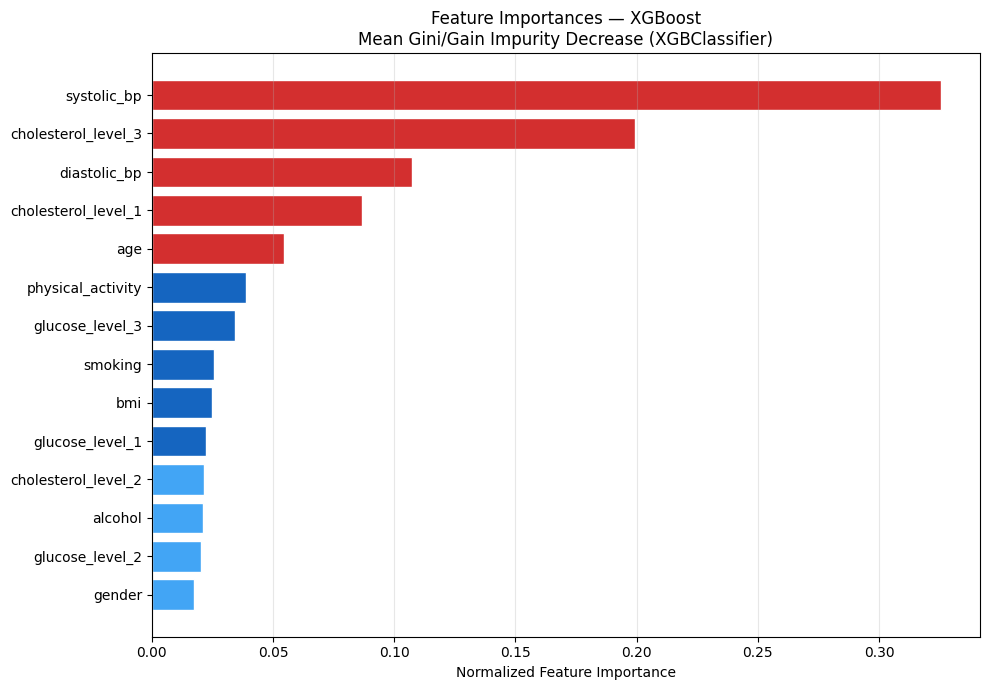


✅ Feature importance figure: /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/lifestyle_feature_importance.png
✅ Feature importance CSV   : /content/drive/MyDrive/CAD_DT_Final/Outputs/Models/lifestyle_feature_importance.csv

  ✅ NOTEBOOK 5 COMPLETE
  Best model : XGBoost (AUC=0.7971, Brier=0.1824)
  Saved      : /content/drive/MyDrive/CAD_DT_Final/Outputs/Models/lifestyle_pipeline.pkl
     → CalibratedClassifierCV(Pipeline([StandardScaler, clf]), cv=5)
     → NB9: pipeline.predict_proba(X_raw)[:, 1]


In [7]:
print("=" * 65)
print("  SECTION 7: Feature Importance Analysis")
print("=" * 65)
print(f"  Best model: {BEST_MODEL_NAME}")

from sklearn.inspection import permutation_importance

TREE_BASED_MODELS = ['XGBoost', 'Random Forest']
LINEAR_MODELS     = ['Logistic Regression', 'SGD Classifier']

importances       = None
importance_std    = None
importance_method = None

def get_inner_clf(calibrated_model):
    """Extract inner clf from CalibratedClassifierCV(Pipeline([scaler, clf]))."""
    # calibrated_classifiers_ is a list of fitted calibrated estimators
    inner_pipe = calibrated_model.calibrated_classifiers_[0].estimator
    return inner_pipe.named_steps['clf']

inner_clf = get_inner_clf(best_fitted)

if BEST_MODEL_NAME in TREE_BASED_MODELS:
    importances = inner_clf.feature_importances_
    importance_method = f'Mean Gini/Gain Impurity Decrease ({type(inner_clf).__name__})'
elif BEST_MODEL_NAME in LINEAR_MODELS:
    coef = inner_clf.coef_
    importances = np.abs(coef[0] if coef.ndim > 1 else coef)
    importance_method = f'Absolute Coefficient ({type(inner_clf).__name__})'
else:
    importance_method = 'Permutation Importance (mean AUC drop, 10 repeats)'
    print("  Computing permutation importance...")
    perm = permutation_importance(
        best_fitted, X_test, y_test,
        scoring='roc_auc', n_repeats=10,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    importances    = perm.importances_mean
    importance_std = perm.importances_std

feat_imp_df = pd.DataFrame({
    'Feature':    FEATURE_COLS,
    'Importance': importances,
    'Method':     importance_method,
    'Model':      BEST_MODEL_NAME,
})
if importance_std is not None:
    feat_imp_df['Importance_std'] = importance_std

feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).reset_index(drop=True)
imp_sum = feat_imp_df['Importance'].sum()
feat_imp_df['Importance_normalized'] = feat_imp_df['Importance'] / imp_sum if imp_sum > 0 else feat_imp_df['Importance']

TOP_N = min(15, len(feat_imp_df))
print(f"\n📊 Top {TOP_N} Features:")
print(feat_imp_df.head(TOP_N)[['Feature','Importance','Importance_normalized']].round(6).to_string(index=False))

top3 = feat_imp_df.head(3)['Feature'].tolist()
if 'systolic_bp' in top3:
    print("\n  ✅ Clinical validation PASSED: systolic_bp in top 3.")
else:
    print(f"  ⚠️  systolic_bp not in top 3: {top3}")

feat_imp_fig = os.path.join(FIG_DIR, 'lifestyle_feature_importance.png')
bar_colors = ['#d32f2f' if i<5 else '#1565C0' if i<10 else '#42A5F5' for i in range(TOP_N)]
top_f = feat_imp_df.head(TOP_N)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(TOP_N), top_f['Importance_normalized'].values, color=bar_colors, edgecolor='white')
ax.set_yticks(range(TOP_N)); ax.set_yticklabels(top_f['Feature'].values, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Normalized Feature Importance')
ax.set_title(f'Feature Importances — {BEST_MODEL_NAME}\n{importance_method}')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(feat_imp_fig, dpi=300, bbox_inches='tight'); plt.show()

feat_imp_df.to_csv(FEAT_IMP_OUT, index=False)
print(f"\n✅ Feature importance figure: {feat_imp_fig}")
print(f"✅ Feature importance CSV   : {FEAT_IMP_OUT}")

print()
print("=" * 65)
print("  ✅ NOTEBOOK 5 COMPLETE")
print("=" * 65)
print(f"  Best model : {BEST_MODEL_NAME} (AUC={BEST_AUC:.4f}, Brier={BEST_BRIER:.4f})")
print(f"  Saved      : {PIPELINE_OUT}")
print(f"     → CalibratedClassifierCV(Pipeline([StandardScaler, clf]), cv=5)")
print(f"     → NB9: pipeline.predict_proba(X_raw)[:, 1]")
print("=" * 65)


In [8]:
print(type(best_fitted))

<class 'sklearn.calibration.CalibratedClassifierCV'>
